LSTM

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# Generate a simple sinusoidal sequence
data_points = 200
time = np.linspace(0, 10 * np.pi, data_points)
data = np.sin(time) + np.random.normal(scale=0.1, size=data_points)

# Define a function to create sequences for LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 10 # Number of previous time steps to consider
X, y = create_sequences(data, sequence_length)

# Reshape X for LSTM input (samples, time steps, features)
# Our data has 1 feature per time step
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Shape of X (input sequences): (190, 10, 1)
Shape of y (target values): (190,)
Training set size: 152 samples
Testing set size: 38 samples


In [3]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)), # LSTM layer with 50 units
    Dense(1) # Output layer with a single unit for predicting the next value
])

model.compile(optimizer='adam', loss='mse') # Using Adam optimizer and Mean Squared Error loss

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.4218 - val_loss: 0.3295
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3268 - val_loss: 0.2438
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2487 - val_loss: 0.1825
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1904 - val_loss: 0.1484
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1573 - val_loss: 0.1345
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1376 - val_loss: 0.1141
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1177 - val_loss: 0.0969
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1002 - val_loss: 0.0833
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0804 - val_loss: 0.0632
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0544 - val_loss: 0.0393
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0391 - val_loss: 0.0693
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0448 - val_loss: 0.0365
E

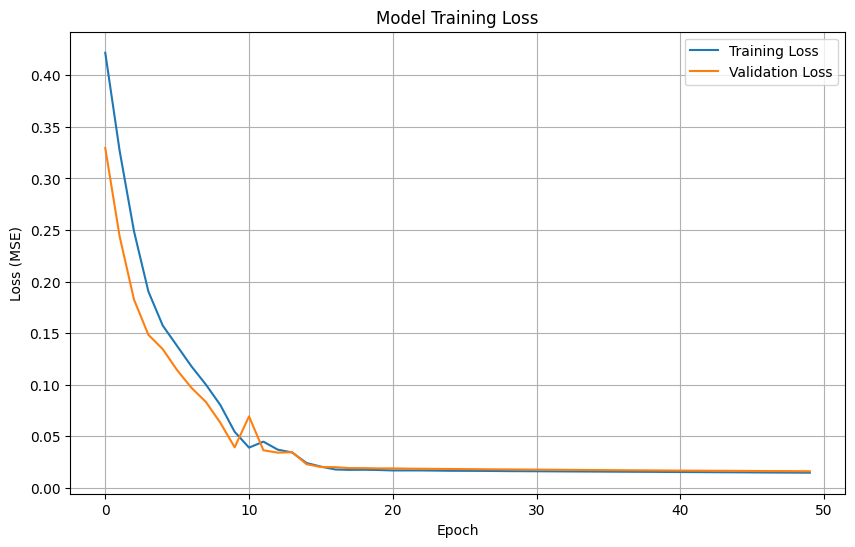

In [4]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1, validation_split=0.2)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Test Loss (MSE): 0.0119
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


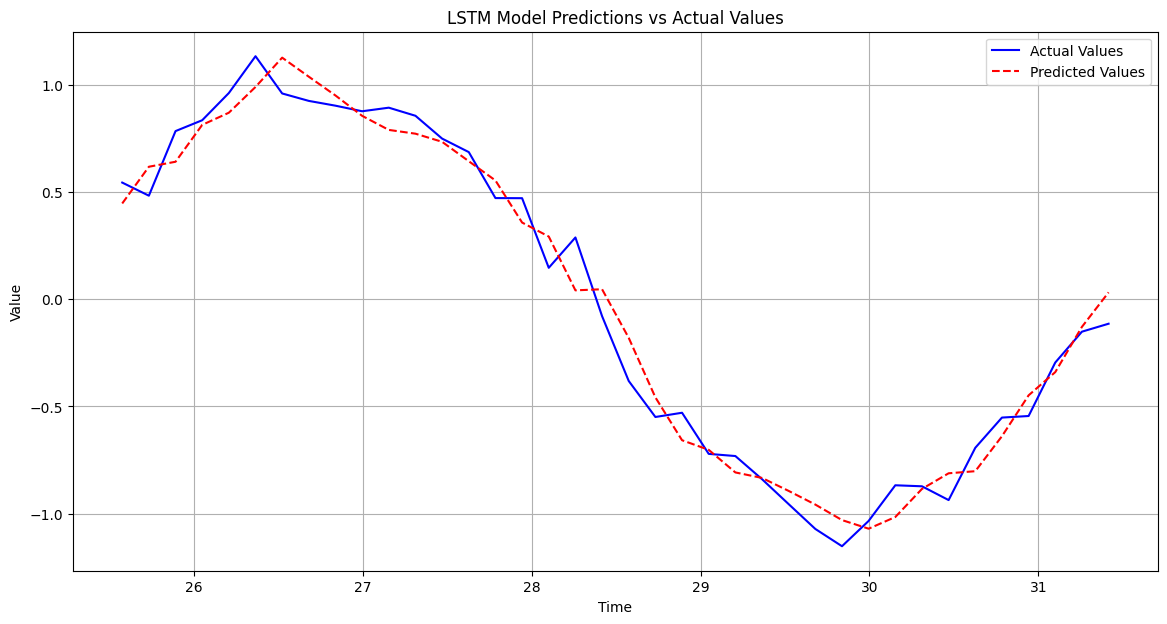

In [5]:
# Evaluate the model on the test set
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Visualize predictions vs actual values
plt.figure(figsize=(14, 7))
plt.plot(time[train_size + sequence_length:], y_test, label='Actual Values', color='blue')
plt.plot(time[train_size + sequence_length:], y_pred.flatten(), label='Predicted Values', color='red', linestyle='--')
plt.title('LSTM Model Predictions vs Actual Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()